In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
import numpy as np

import random
from typing import Tuple, List, Optional
import matplotlib.pyplot as plt
from datetime import datetime
import copy



import lightning as pl
from lightning.pytorch.loggers import WandbLogger
import wandb
import pprint

import monai
from monai.losses import DiceLoss, DiceCELoss, SoftclDiceLoss, DiceFocalLoss, NACLLoss
from kornia.losses import total_variation

from Models.model import MLP, initialize_siren_weights, SineLayer, ReLULayer
from Models.model_trainer import ModelTrainerModule



from Models.models import Siren, Finer

from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_data_3d import load_data, get_gt_seg
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images
from LFSynth.ContrastModulation import ContrastModulation

from Data.patchwise3D import RandomPointsDataset

In [6]:
from onnxruntime import InferenceSession
import onnx

In [2]:
POINTS_PER_SAMPLE = 96*96*4
lf_points_per_sample = 48*48*4

In [4]:
config = copy.deepcopy(default_config)
config["in_features"] = 3
config["l1"] = 100 #wandb.config.l1
config["l3"] = 8 #wandb.config.l3
config["l4"] = 0.075
config["l5"] = 0.09
hf_ground_truth, lf_gt, prior_seg_dice, lf_gt_seg_dice, M = load_data(1, config) #uncomment
gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
gt_image = gt_image.to(torch.float32)
lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
lf_gt = lf_gt.to(torch.float32)
print("gt_image: ", gt_image.shape, "lf_gt: ", lf_gt.shape, "lf_gt_seg_dice: ", lf_gt_seg_dice.shape)
print('gt_image, lf_gt loaded')


dataset = RandomPointsDataset(gt_image, lf_gt, lf_gt_seg_dice, points_num=POINTS_PER_SAMPLE)
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, pin_memory=False) # We set a batch_size of 1 since our dataloader is already returning a batch of points.


Device =  mps
torch.Size([87, 96, 192])
BG Noise in different regions : 4.7445857300717 4.415978248235479 4.956849146645869 4.8247938816077935
known_m =  [0.75 0.9  0.9 ]
[[ 28.84998854   0.          -7.89492106]
 [ 28.84998854 -22.35619149   0.        ]
 [  0.          22.35619149  -7.89492106]] [14.53206245  1.51691906 13.01514339]


delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.


             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [144.631340676391, 144.63133495698293, 144.631...   
1   [144.63164067639102, 144.63163495701272, 144.6...   
2   [144.632840676391, 144.63283495713193, 144.632...   
3   [144.634340676391, 144.63433495728094, 144.634...   
4   [144.637340676391, 144.637334957579, 144.63733...   
..                                                ...   
59  [26.521283391070423, 26.521282393240874, 26.52...   
60  [26.596283391070422, 26.596282394730988, 26.59...   
61  [26.671283391070425, 26.671282396221105, 26.67...   
62  [26.746283391070424, 26.74628239771122, 2


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


(87, 96, 192) (87, 96, 192) (174, 192, 192) 28.849988539317234 [0.60813009 0.71692118 0.38157238]
torch.Size([87, 96, 192])
pixels shape =  torch.Size([1603584, 1])
torch.Size([1, 6414336]) torch.Size([1, 4, 174, 192, 192]) torch.Size([1, 1603584]) torch.Size([1, 4, 87, 96, 192])
gt_image:  torch.Size([174, 192, 192, 1]) lf_gt:  torch.Size([87, 96, 192, 1]) lf_gt_seg_dice:  torch.Size([1, 4, 87, 96, 192])
gt_image, lf_gt loaded
Device =  mps


In [14]:
model_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/saved_models/model0.onnx"
onnx_model = onnx.load(model_loc)
onnx.checker.check_model(onnx_model)

onnx_model.graph.input[0].type.tensor_type.shape.dim[0].ClearField('dim_value')
onnx_model.graph.input[0].type.tensor_type.shape.dim[1].ClearField('dim_value')
# onnx_model.graph.input[0].type.tensor_type.shape.dim[2].ClearField('dim_value')
# onnx_model.graph.input[0].type.tensor_type.shape.dim[3].ClearField('dim_value')
sess = InferenceSession(onnx_model.SerializeToString())

In [15]:
onnx_model.graph.input[0].type.tensor_type.shape

dim {
}
dim {
}

In [17]:
dummy_input, _ , _ = next(iter(dataloader))
dummy_input = dummy_input.view(-1, dummy_input.shape[-1])
sess.run(None, {"onnx::Gemm_0" : dummy_input.cpu().numpy()})

[array([0.04753159, 0.29973316, 0.02868612, ..., 0.02423261, 0.02033468,
        0.6575778 ], dtype=float32),
 array([0.04753159, 0.29973316, 0.02868612, ..., 0.02423261, 0.02033468,
        0.6575778 ], dtype=float32),
 array([[0.95684844, 0.01620794, 0.01922962, 0.00771407],
        [0.09373604, 0.08897708, 0.13347888, 0.683808  ],
        [0.96298915, 0.01354713, 0.01699901, 0.00646468],
        ...,
        [0.96393394, 0.01323843, 0.01672112, 0.00610656],
        [0.95782495, 0.01560836, 0.01951476, 0.00705193],
        [0.08908514, 0.7957052 , 0.08219773, 0.033012  ]], dtype=float32),
 array([[ 3.5584073 , -0.51973623, -0.34878582, -1.262191  ],
        [-0.58022934, -0.6323331 , -0.22676872,  1.4069653 ],
        [ 3.6993995 , -0.564468  , -0.33748755, -1.3042897 ],
        ...,
        [ 3.7092614 , -0.5786371 , -0.34508914, -1.3523984 ],
        [ 3.5890222 , -0.5278362 , -0.30447206, -1.3223413 ],
        [-0.22754207,  1.9620942 , -0.30800676, -1.2202636 ]],
       dtype=flo

In [30]:
resolution = hf_ground_truth.shape
device = 'cpu' #get_device()
meshgrid = torch.meshgrid([torch.arange(0, i, device=device) for i in resolution], indexing='ij')
coords = torch.stack(meshgrid, dim=-1)
coords_norm = coords / torch.tensor(resolution, device=device) * 2 - 1
coords_norm_ = coords_norm.reshape(-1, coords.shape[-1])
predictions_, _, pred_seg_, _ = sess.run(None, {"onnx::Gemm_0" : coords_norm_.cpu().numpy()})
predictions = predictions_.reshape(resolution)
resolution_seg = list(resolution) + [pred_seg_.shape[-1]] #adding num_tissues to the resolution shape
pred_seg_ = pred_seg_.reshape(resolution_seg)
pred_seg = [pred_seg_[:,:,:,i].reshape(resolution) for i in range(pred_seg_.shape[-1])]


2025-09-08 17:48:25.036773 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {6414336,4} for output input.3
2025-09-08 17:48:25.537905 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {6414336,4} for output 48
2025-09-08 17:48:25.581711 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {6414336} for output input
2025-09-08 17:48:25.694391 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {6414336} for output 47


In [31]:
pred_seg = np.stack(pred_seg, axis = 0)

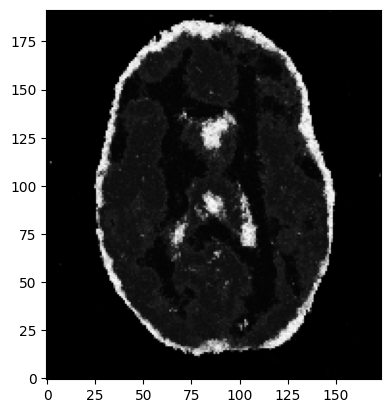

In [39]:
plt.imshow(pred_seg[3,:,:,95].T,cmap='gray')
plt.gca().invert_yaxis()